# 🪔 Diwali Sales Data Analysis

This notebook performs an end-to-end analysis of Diwali sales data — from data cleaning to exploratory data analysis (EDA) — to uncover customer buying patterns and business insights.

## 1. Importing Required Libraries
We start by importing the libraries needed for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset
We load the Diwali Sales CSV file. `encoding='cp1252'` is used because the file was originally exported from Excel, which does not save CSVs in UTF-8 by default.

In [14]:
ff = pd.read_csv('C:/Users/md sahil/OneDrive/Desktop/MY_EXCEL_FILES/Diwali Sales Data.csv', encoding='cp1252')

## 3. Initial Data Exploration
Before cleaning, we check the shape, first few rows, and structure of the dataset to understand what we're working with.

### 3.1 Dataset Shape

In [16]:
ff.shape

(11251, 15)

### 3.2 First 10 Rows

In [18]:
ff.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


### 3.3 Column Info & Data Types

In [19]:
ff.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


**Conclusion:** The dataset contains multiple columns describing customer demographics (Gender, Age Group, Occupation), location (State, Zone), and purchase details (Amount, Orders, Product Category). Some columns have missing or irrelevant data, which we address in the next section.

## 4. Data Cleaning
Raw data is rarely analysis-ready. Here we remove unnecessary columns, handle missing values, and fix data types.

### 4.1 Dropping Unnecessary Columns
The `Status` and `unnamed1` columns are empty/irrelevant and are removed.

In [23]:
ff.drop(['Status','unnamed1'], axis=1, inplace=True)

### 4.2 Checking for Null Values
We check how many missing values exist in each column.

In [25]:
pd.isnull(ff).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

### 4.3 Removing Rows with Missing Values

In [27]:
ff.dropna(inplace=True)

### 4.4 Verifying Shape After Cleaning

In [28]:
ff.shape

(11239, 13)

In [30]:
ff.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

**Conclusion:** All null values have been removed, and the dataset is now free of missing data — ready for accurate analysis.

### 4.5 Fixing Data Types
`Amount` was stored as a float; converting it to `int` makes it easier to read and work with, since currency values here don't need decimal precision.

In [31]:
ff['Amount']=ff['Amount'].astype(int)

In [33]:
ff['Amount'].dtypes

dtype('int64')

**Conclusion:** The `Amount` column is now correctly typed as an integer, completing the data cleaning process.

## 5. Dataset Overview After Cleaning
A quick look at the final column list and summary statistics.

In [37]:
ff.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

In [39]:
ff.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


**Conclusion:** The dataset is now clean and structured, with numerical summary statistics (mean, min, max, etc.) available for the `Amount` and `Orders` columns, giving us a baseline understanding of spending behavior before deeper analysis.

## 6. Exploratory Data Analysis (EDA)
Now that the data is clean, we explore it visually to uncover patterns in customer behavior, demographics, and sales performance.

### 6.1 Gender Distribution
How many customers are Male vs Female?

[Text(0, 0, '7832'), Text(0, 0, '3407')]

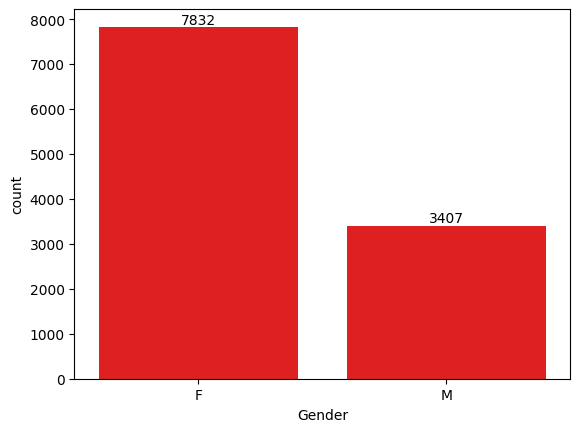

In [43]:
ax = sns.countplot(x='Gender', data=ff,color='red')
ax.bar_label(ax.containers[0])

**Conclusion:** Female customers significantly outnumber male customers in this dataset, suggesting that Diwali shopping (at least in this data) is driven more by female buyers.

### 6.2 Total Amount Spent by Gender
While Section 6.1 shows *how many* customers exist per gender, this shows *how much* each gender group actually spent.

<Axes: xlabel='Gender', ylabel='Amount'>

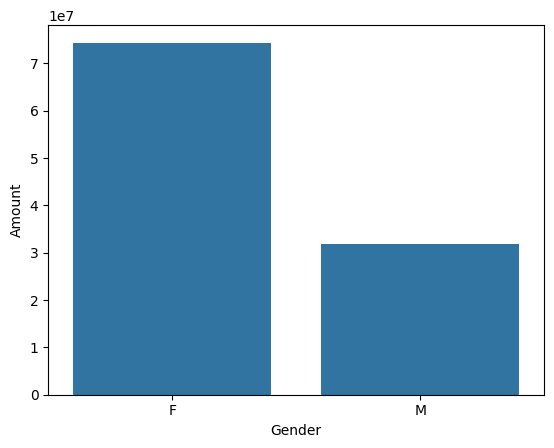

In [50]:
pl=ff.groupby('Gender', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x='Gender', y='Amount', data=pl)

**Conclusion:** Total spending follows the same trend as customer count — the gender with more customers also contributes more total revenue, confirming that gender is a key factor in purchase volume.

### 6.3 Age Group Distribution by Gender
Breaking down customer count by both Age Group and Gender helps identify which age segment is most active.

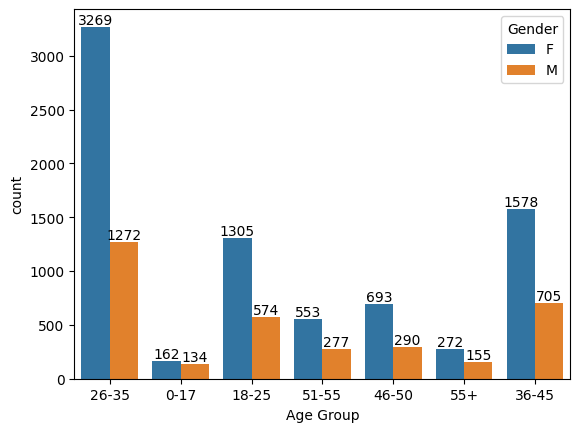

In [65]:
ag=sns.countplot(data=ff,x='Age Group',hue='Gender')

for bar in ag.containers:
    ag.bar_label(bar)


**Conclusion:** Certain age groups show noticeably higher customer counts than others, and this pattern remains fairly consistent across genders — highlighting the core target age demographic for future marketing.

### 6.4 Total Amount Spent by Age Group
Which age group contributes the most revenue?

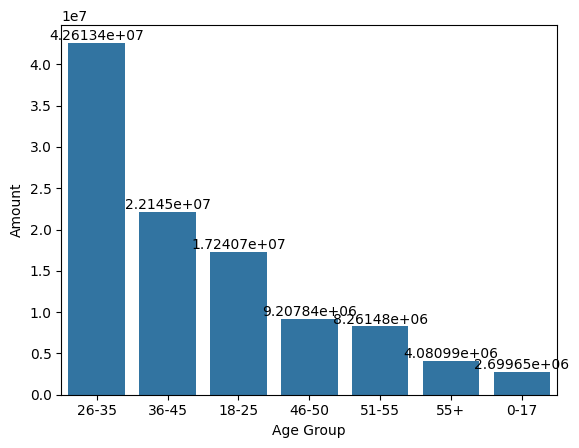

In [66]:
sales_age=ff.groupby("Age Group",as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sn=sns.barplot(x='Age Group',y='Amount',data=sales_age)

for bar in sn.containers:
    sn.bar_label(bar)

**Conclusion:** The age group with the highest customer count also tends to generate the highest total sales, making it the most valuable segment to target for promotions.

### 6.5 Top States by Number of Orders
Which states generate the highest order volume (number of transactions)?

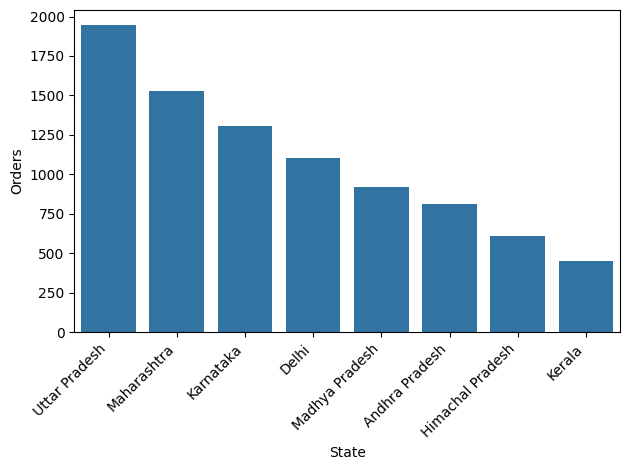

In [76]:
state_orders=ff.groupby("State",as_index=False)['Orders'].count().sort_values(by='Orders',ascending=False).head(8)


ax = sns.barplot(data=state_orders, x='State', y='Orders')
plt.xticks(rotation=45, ha='right')   
plt.tight_layout()                     
plt.show()

**Conclusion:** A small number of states account for a disproportionately large share of total orders, indicating strong regional concentration in customer base.

### 6.6 Top States by Sales Amount
Which states generate the highest revenue (total ₹ amount)?

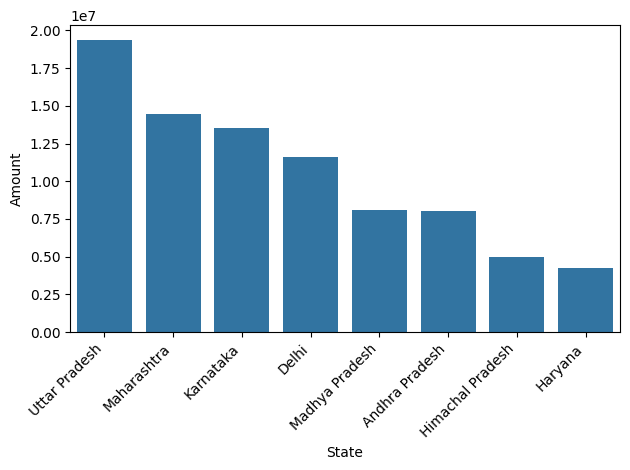

In [77]:
state_orders=ff.groupby("State",as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(8)


ax = sns.barplot(data=state_orders, x='State', y='Amount')
plt.xticks(rotation=45, ha='right')   
plt.tight_layout()                     
plt.show()

**Conclusion:** The states leading in order volume also tend to lead in revenue, confirming that these regions are the most important markets for the business.

### 6.7 Sales by Gender & Marital Status
Does marital status combined with gender affect spending patterns?

<Axes: xlabel='Marital_Status', ylabel='Amount'>

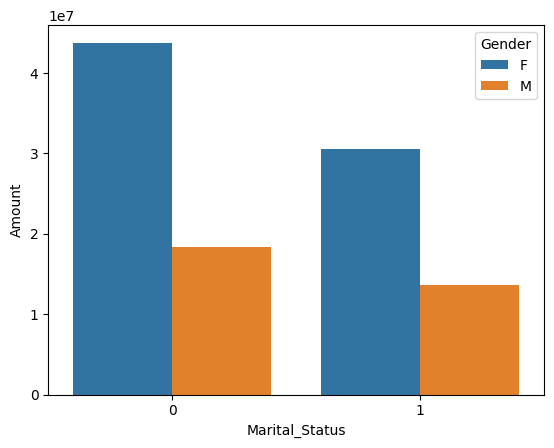

In [84]:
couple_sales=ff.groupby(['Gender','Marital_Status'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(data=couple_sales,x='Marital_Status',y='Amount',hue='Gender')

**Conclusion:** Spending patterns vary across the combination of gender and marital status, which can help tailor marketing messages to specific customer segments (e.g. married women vs. unmarried men).

### 6.8 Customer Distribution by Occupation
Which occupations are most represented among customers?

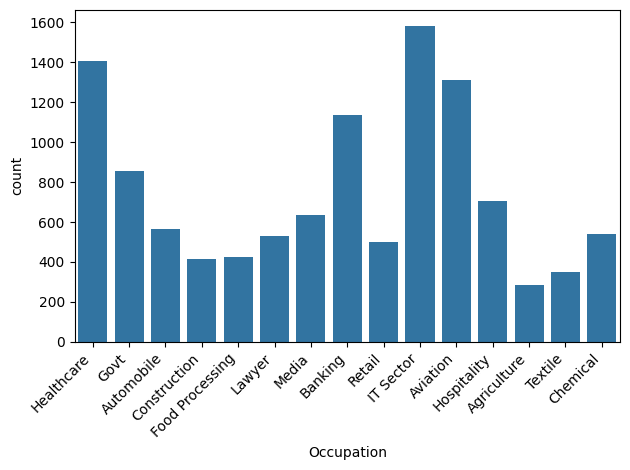

In [87]:
sns.countplot(data=ff,x="Occupation")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusion:** Certain occupations are far more represented than others, suggesting the product/brand may particularly resonate with specific professional groups.

### 6.9 Total Amount Spent by Occupation
Which occupation groups contribute the most revenue?

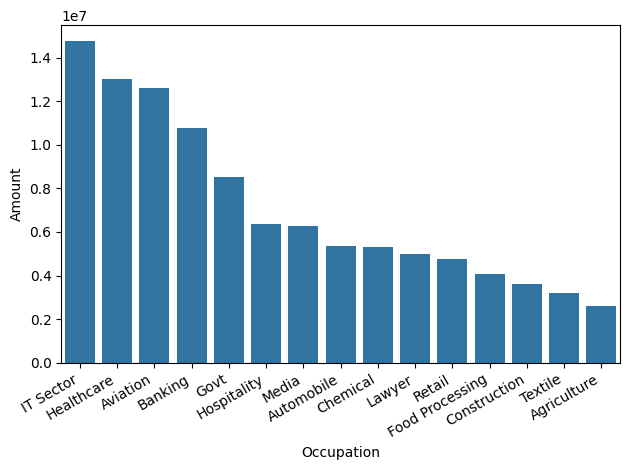

In [92]:
occ_purchase=ff.groupby(["Occupation"],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(data=occ_purchase,x='Occupation',y='Amount')
plt.xticks(rotation=30,ha='right')
plt.tight_layout()
plt.show()

**Conclusion:** The occupations with the highest customer counts generally also drive the highest revenue, reinforcing where the core customer base lies.

### 6.10 Amount Spent by Product Category (Raw)
A first look at spending across product categories using the raw (uncleaned/ungrouped) data, including confidence intervals.

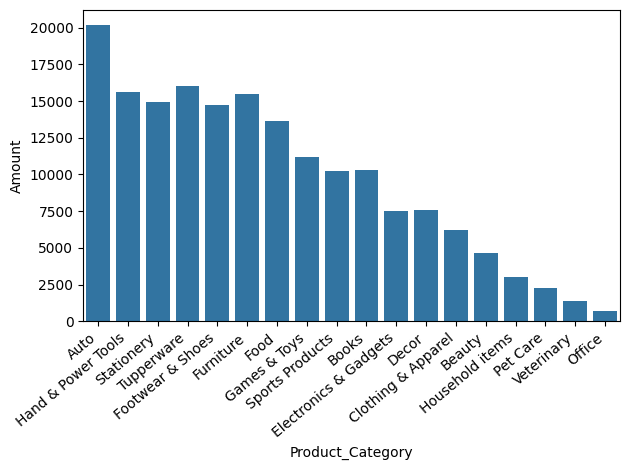

In [98]:
sns.barplot(x='Product_Category', y='Amount', data=ff, errorbar=None)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()          
plt.show()

**Conclusion:** Some product categories show wide variability in transaction amounts (larger spread), while others are more consistent — useful to know for inventory and pricing strategy.

### 6.11 Top 8 Product Categories by Total Sales
Aggregating and ranking product categories by total revenue gives a clearer picture than the raw view above.

<Axes: xlabel='Product_Category', ylabel='Amount'>

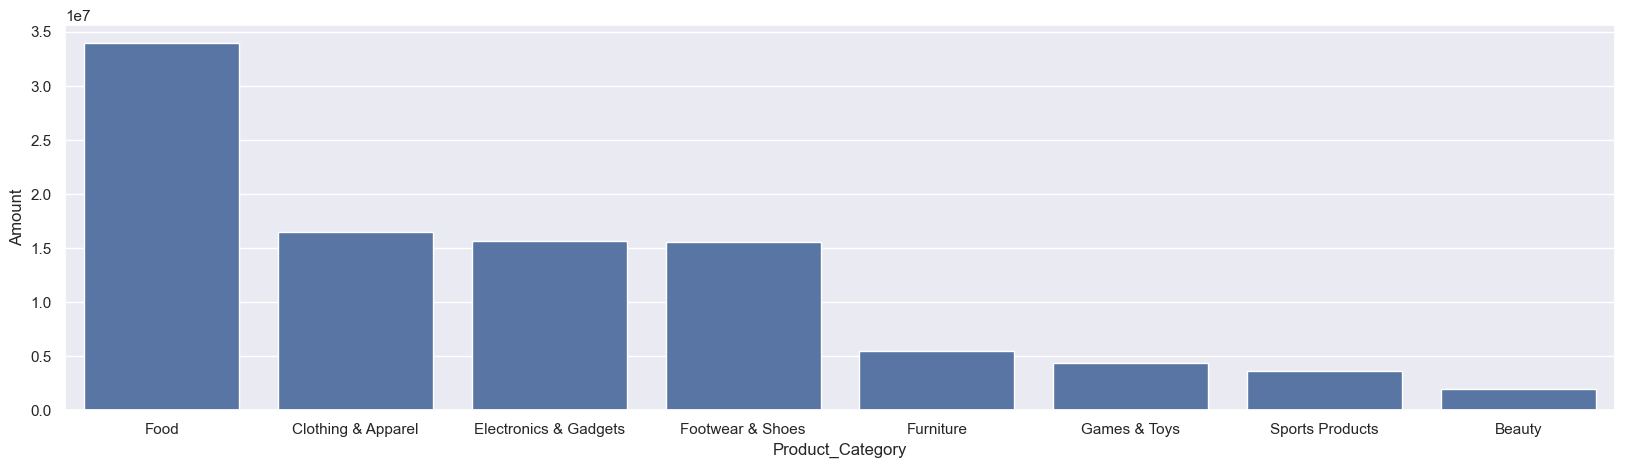

In [103]:
product_sales=ff.groupby("Product_Category",as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(8)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=product_sales,x='Product_Category',y='Amount')


**Conclusion:** A handful of product categories drive the majority of total sales, making them the top priority for stock planning and promotional focus during festive seasons.

### 6.12 Top 8 Best-Selling Products (by Product ID)
Zooming in further — which individual products generated the most revenue?

<Axes: xlabel='Product_ID', ylabel='Amount'>

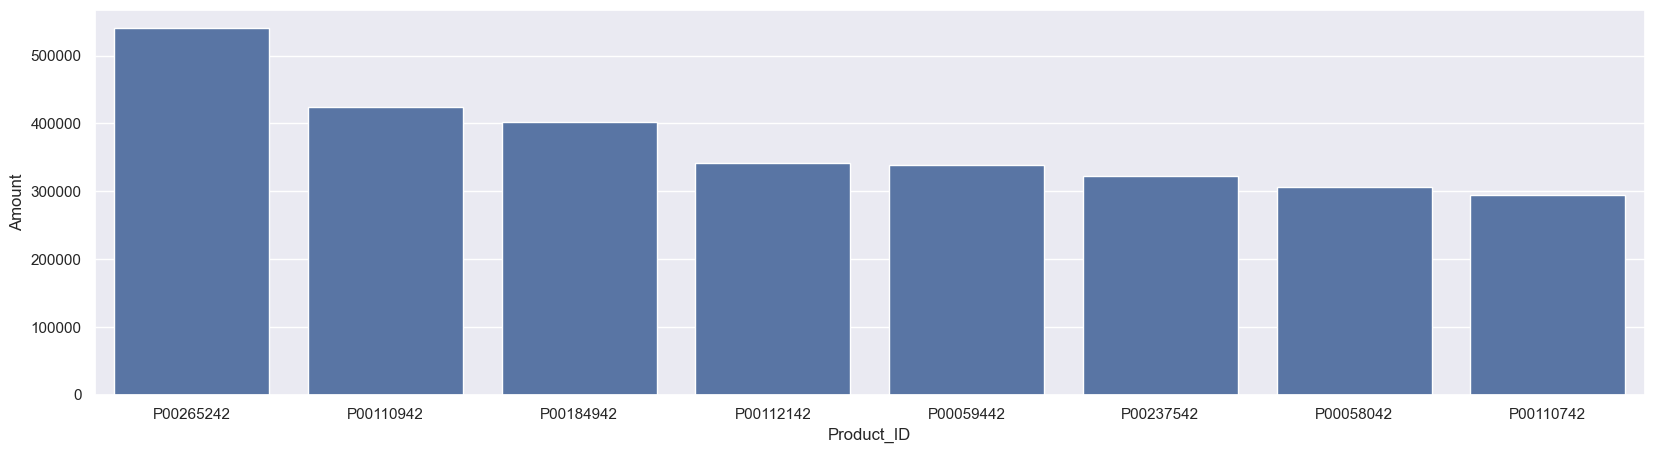

In [106]:
pro_name=ff.groupby("Product_ID",as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(8)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=pro_name,x='Product_ID',y='Amount')

**Conclusion:** A small set of specific products account for the highest sales, making them strong candidates for restocking priority and bundled promotions in future campaigns.

## 7. Overall Conclusion

Based on this analysis of the Diwali Sales dataset:

- **Gender:** Female customers dominate both in count and total spending.
- **Age Group:** A specific age segment leads in both customer count and revenue, making it the primary target demographic.
- **Geography:** Sales are concentrated in a handful of states, both by order volume and revenue.
- **Marital Status & Gender:** Spending patterns differ meaningfully across these combined segments.
- **Occupation:** Certain professional groups are overrepresented and drive a larger share of revenue.
- **Products:** A small number of product categories and specific products account for the bulk of total sales (the classic 80/20 pattern).

**Business takeaway:** Marketing, inventory, and promotional efforts during festive seasons like Diwali should prioritize the top-performing states, age groups, and product categories identified above, since they consistently drive the highest customer engagement and revenue.